<a href="https://colab.research.google.com/github/Brenuzy/banco-de-dados-2ds/blob/main/2ds_experimento_visao_computacional_com_Python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#EXPERIMENTO: algoritmo para classificação de imagens com Python

SALVE UMA CÓPIA DESTE NOTEBOOK NO SEU DRIVE ANTES DE EXECUTÁ-LO!

Erro ao baixar os rótulos do ImageNet: No connection adapters were found for ''
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth

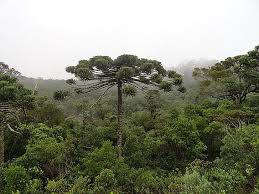

100%|██████████| 97.8M/97.8M [00:00<00:00, 129MB/s]


Iniciando a classificação da imagem...


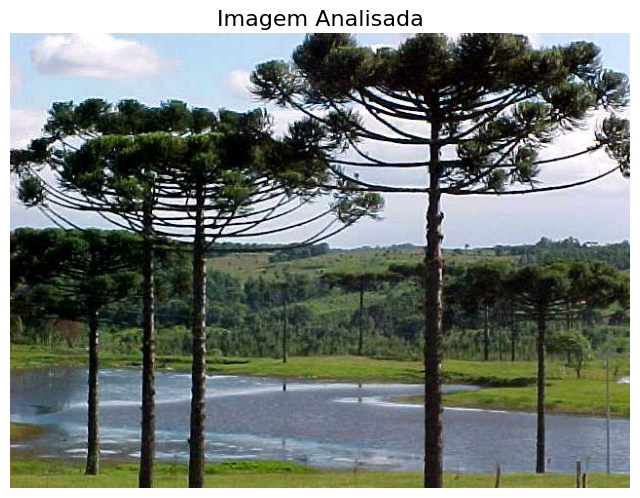


--- Resultado da Classificação ---
Classificação: Desconhecido 733
Nível de Confiança: 37.45%

--- Resumo da Execução ---
Este algoritmo realizou a classificação da imagem fornecida usando um modelo de rede neural convolucional pré-treinado (ResNet50), treinado na base de dados ImageNet. A imagem foi primeiramente baixada da URL e pré-processada (redimensionada, cortada e normalizada) para se adequar à entrada do modelo. Em seguida, o modelo inferiu a classe mais provável da imagem e calculou o nível de confiança para essa previsão. A classificação foi apresentada no idioma português, com base em um mapeamento simples para classes comuns ou utilizando o nome original da classe ImageNet quando a tradução direta não estava disponível. O resultado final inclui a imagem analisada, a classificação em português e o percentual de acerto, seguido por este resumo explicativo.(Classe original ImageNet: Desconhecido 733)


In [3]:
import requests
from PIL import Image
import io
import torch
import torchvision.transforms as transforms
import torchvision.models as models
import torch.nn.functional as F
import matplotlib.pyplot as plt
import json

# Desativar avisos de depreciação do `pretrained=True`
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module='torchvision')

# URL para os rótulos das classes do ImageNet
LABELS_URL = "data:image/jpeg;base64,/9j/4AAQSkZJRgABAQAAAQABAAD/2wCEAAkGBxMSEhUREhMWFhUXFxcaGRUWFhgZGBgYGBgZGBgYGR4YIiggGRslGxgYITEhJSktLi4uGR8zODMsNyotLisBCgoKDg0OGhAQGy0gHyUtLS0tLS8rLS0tLS0tLS0tLS0tLS0tKy0tLS0tLS0tLS0tLS0tLS0tLS0tLS01LS0tLf/AABEIAMIBAwMBIgACEQEDEQH/xAAcAAACAwEBAQEAAAAAAAAAAAAABAIDBQEGBwj/xABAEAACAQIFAgQDBQcDAwMFAAABEQIAIQMEEjFBUWEFInGBEzKRBkKhsfAUI1JiwdHhB3LxgpKyFTNTFkNjoqP/xAAZAQEBAQEBAQAAAAAAAAAAAAAAAQIDBAX/xAAkEQEBAAIBAwQDAQEAAAAAAAAAAQIRIRIxQQMTMlFhcYEzBP/aAAwDAQACEQMRAD8A+1gVN1GiqJV0VwV0UEqK5XagKKKKAooooCiiigKKKKAooooCiiigKKKKAooooCiiigKKKKAorlFAVyg1yqjhqMhUjUTQVKipqig667Ua7RUgakKgK66CYrtQddBqCdFRdDoJUVx0UHaK5Q6DtcrjrtB2iouiglRXKKDtFcooO0Vx0UHa5RXHQddFcrlB2iuOuVR11yiuUQVyiig5RRRQQBqTqFddFSdSFQdddQSddqFddBKuuouuuipOh1Gh0RJ0Oo0UEnQ6i6HQSodRrroJUVx0Og66K4646DrodRJodBJ1yuUUHaHXHXKDtDrlFB2iiuVUBooqrMY0YRlOZUYgkk8Ab0Fldrx+N/qPkIyMdcyuRhyR9GjXaz1QeoBrrrP8N8UwscE4U9QG9iPzFOg1VTBqTqsGpA0VN0Oouh0E3XXVbodBY6HUHSviWdGDhTxpAkQiZERuSB60Q66HXz2X+pkQb5aQj1OJffjyo24e/PNeU+032zx8xiGEZmOCTaChsuqZt1N3WeueB9rGLElAh9GHbeuiVfngZ/DPlGp7O0R7La1NeD+Nzyk44mFNAlkEbgEHSVuLgHbj2zPU/A+/OsvMfaTKYcjGeYwxIbjU1dIrYv8ArXzD7Wf6gSzEPhRAw4ERMg2SVeJOxiza3ArweJmzIkAEgDccLc22rW/ofpHK+OZbEKhj4UjewnF23s3Wg6/MuFnpERX0+v4L9dPaZL7d5jBwhgw0qCETpiSBexB3bCS+Xl1Or7H2V0E1808P/wBRsbS8XA1EkLTGUfKvMxe+/o/atLIf6k5eZPxITw4heb5t9mAAR+NWZwe4dDpfK5mOJCOJAuMwJRKIYIYKNx71ZqrQsdDqnExgNzS+JnhHffgCgddDrPHiATPt+jVZz63LoNWh1kYnjIGw+prMz325y2FDXfEuRIYRjPQB96RYQ4s72qbkHqnUMXFjEapSER1kQB9TXxLx3/ULGxcXXhY08OMZeWA8oQJWpE6idiytkBzkeJZ/FzMzjYuohEqU5JgagI7mBRHIHLsaz7n1DT7lmftDloA/v8KUkFEYkSyfl2afWvlH2k/1Px5asLRCAIIlHcg7EOXQ8hXHSvF5vxglROnjyBBDldDYDnmoYksFBmRO6w9EIoqQ3D9QmxxzzudvdG3geKYMI6Z5eMpBuUcSIBJJNhpPVdOlFea+DKNonEIGxABHsdYf0orX9V9Dw8rKUvi4MxhECIkYHERVn5Rt5RL2DLNe2yH2yw5GEDErTH4mJqYjIgX2UotuTG8bFqvk/wD9RaBogLFAgW1cIq5R4Pcp3rWy3jWHpJkfnI1BsxIJEdJ3aZtfzH1pM/4u32jLZiOJEThISidpRIIKsbjvVwNfOfB/G44Uvi4eGNMgAYiaf8xtv2IQFgq9PgfafBMXISieQn9CN/wrpsegdDrL/wDW8HTqEwe20voVV+W8Qw5x1RkFtcgXT602HTKjVSkM9hyJAnEkbog/r/BqQzMFq1RXXUF9dqDw/wBsPtpmMvjywcOMY6eTFmQQlbVZJ3A97V5Xxf7VZnM4cYYmMo+aZ0gRY1GMWIiL55S719W8WnltJGYOEAYyH7zQyCLrVc+1fP8A7TfZDCkRjZQYccI4YCBfQuQHBBF279E8ZQeNGYhK4xJEd4gkFju+Rtwqd8A8Mw8TH0ZiE5QmDolhygJCRuAY6hIsES8tz5eC6wMzCUSdUQDErcG7IiPKWTfYM6Yg7JbfgHiZwpOOICJADUCJhfMNUIanzYiz7VnGaoV8Z+zuYwNcjCQwxK0pYc8Pm3lxACLgbPcXLdLZDBMvLKejkicZEkO60gmR2C0pMkjY7Od8ezRBwonDlAj5RhzhFJqQw4RBH9RXn8TwzFg5KEdrCNvY4mGBEW5PvWxHN4WGSI4U8OUjKQERIlBahIkEF8XiB+dMTw8CAEDCUu4kI9U1EokCloZqWGJasUzJAZ1CSCsCRImJctjSccWRFiCNXysatiNnqXW3S9Zu6NeODhxWJFyiC5RmRcC+kEAGPIdTlmMJa8LDk7mV3GIcUI6r78klsbcr+DZeOK4HGwsKR4xzOI3DuI6RYrzSj6KtrRHIyEBox4zjyME4bsyF8UHcXcT5Rty19jz8MWeJOMSTEkx+ZhiS0n02L5fpWp4vkcTBEcQgSErylE6hC6DRYO1yAjIdnrmOUGH+0mUDOx+FGUN4HUDIShhaWQNXw91yG8rO+P42YeFKROCQtJ0gBH7my2fFirt0uoPefYT7agxGXx5KQ+QkAAxRYkuWCdRuSS77+mH2rwTICOJAkvytE2fPrXyzwrwUSkcSJiMJ/KyJbIgHz9Ab9drhZmJ4dj4cjPFi/MVIkabk/MHcc87jvTqsg+y5jxAn1I/CyVJHPM3L7/8AFeK8H8fxjLRiyhOLQOpyJ9Rfr332s9WGY3dXHKZB3PfaIwxBGOGJRszGV+pt133PHFI4/wBrTGemWFLSmJAg6uiB4XesCWUkMSR13N9IYFyyepruaEiA7aQN/MPUndWFjb8axvJVvjH2hxJeSHmgYkSsA7lMkrZCxF2q81hYuIyNGncNSjAhgovcbWl061d4hhYkNzYksfifz/5pSOXxJXuRwNUT0ICZIsXtXK3LyLcDJQ+IDiSjpJHliZMiyZFgOOdz6Vdi584B+DC2GCE5XL2Rk1umeOvNWFly3IxSRO5sf5R+lvTGLloyidMQZQFioggAdY7yIHL5Nbl33RlZ3LRMIQcJSEYx0jTIxIf8ADZJv5pF3RdVYXhxIQkRHkAAm7uOUwePyRnm4Yg0yA02G3RDflIoc2PpVMM3JAGL760Rxyx+Va5Ro5eGAIgHEnH+X40orslaiqsPxAoeY/8Adh7cff6UVdm1+BmDieUYMDAAfdESrgiOz24q3C8MN5SiVc6RoABJshfSL7dhWQc2DYSQEQAh0YUuiEjVWXxPOVIq6EiUeOPT8u9c+m+EeyyvjYBEACWiwL32Jtzb8B0rY+Ma8RjSUnJCRUT1kRYEK8l+uW1kc7jeUwEzGwIMe8b3Fhz6E+1mVi7e0jjnQ1Zr8Gf6fXtUDmXWL+1yM9H3QBdfeQMkXcP12+t0T0Jf1VamXlWl+0nr9a58cnn8ayM3nNEDPdcVk4H2iMiGgOQvRAHnzWaFj2Jq9SNnxXw74xMxMg29AhuCivQ/UU54VL4UTET+JHhaWtrh6eBt+QCw8t4sZm6QtY3aLHA6dKj4tGZIMUSUFKRIiNnEWB5Yl/Sm1ekMoN/DABBbEANpd7BTxHb71VYnjMRYGALIIiQb3fmnKEWxcXNYWXlIRUoQJ6k2V/u6bIHZD1q6EusiewcIjoECUQt26uweIZuUzrctQDHw9IMQQCzjTjEYYKT8wtuaT8RyEp+abP8AC8acjKSVzMefqPhRLvWjhY0YXsEz5YgnuRpZkT2DNThjkkz+8k9xEbmL9dyN16Jsec8U8FOHgHEMYwOpER1yJBkEJeYxiuqvYWNNeFeGQxMPDljmXmG5jh7idnriTZLUDGR1Lar/AB/MGWXmNx5P/ONZhniSwoz+YIFMXIMgbKzJGwuqW3XA3cpk8KJJBJJsYmIxInrqwZCX8P3DcmwFqvxvB8tiBmIwmU8AkRkQSFGI8up2WjU7V5nKzxYzGqzIYIkACSQUQCN/dgjavW4kdcFIMkBhnzLq7T/SVSW+RlZDwAwlKWFjwkFKN4CRD8shKMivxCdtnVfiXhAXmjiQMbmUCJwN76gS4ELcFXG9PZvNShaDjwSC+y8+pHtx1lSpzmLqGsnQdwYx26CUER+H9KnVAkfHjhDRCUjpFgSSOSWH7/4ps5jFzGHLSIQN9gA7H+EKR7EBdQQalmvB8OekgRgncAElq5JvsDv+Dq7IZYYEUJmXXYD1SsLdTyWd6kkiMvw3JSwcYSxJCIDlZJpeiACX9xXqZZwC7t1rzXiXhhxpGUZnjyyPlJ4AIDiul/betLKRMICO62lweUH+frWt6DmYzRI5dYmcniS21HsTf0/W9O42IgxzwWX2FZ+DjJkRudwbL8F+jXPLlYZhBQ04hZINiWA/WuYmXIAR0k9DttY8q23aq8PMGTivx2fUbn3qE2G5AgG4JsQL+nSzp0hXNnSxqmwb7EF7H5eoG5DHpVmWz2mJBIkSFve47AMcfjzWf4higf8A3Yg6kQECRa7ZS96Twoz1G0idOrzERG2rkXcbpu3rWuhNNTMZyM4R1W0ocjSOGSf+aTOWlOBxGAQ1Egtb3QIF2NJW1dwwNeFhCMjKYE5Q2YZMOUkDI+o93cTwfGMNPxYh2MYQlN9PMDqvzYJ81eJ3GPPLCRYxCivuxPF7mQ5op7/0PE/hw/8A+vNFXeIzZZPEBISe+rSO4eohcfWro5fzOMhLtqvC/DI22/5rUIiNIjKMiQWhqIt/+PLFGwsb7Vfm/DzIA6xtYiViEmWrW6cHalq6JYxsLkq4sgC7u+46AWPa9Bzkn5J6iGXcdd3ZEnTue/FRz3h4w4mV9ZFoGJ1bStLShq+RIHjYm9GYyhbiXE3BBYZEiDdOx3HU1nUNPQZXMSEHLEZdyTd/UgCx562ruXxZTI8/yy3krdRHe+3RVm5XFUTHFNiLh9F1fQdr+tdOIgo3bDO6OySrnwNXO4YxIGJJR6jY7Dnm9n/Ws2HgaZBfVBSRkJenCt0HWoYWZESSdh3RPP8AQ/WtTKZ+MgtI2va5tv6e/wDWtzKhmDSkR6AJss9EGdhzXfhDl9ttvXp/elsWR2jYf1qrM40ogIrjsR6e396XfgM4mMihAnY7XB25uN/xpj4OoPqAgAr/AKdqysvrKLlIotFlEnfpuPrxam8SQIlEt3Y2J2IF9ohbX68DTN0Sw5gE38obJ+8bjngXCI5PVAxc2tgQT1I257ji1uKTjixjMSYZs9P+bHc+1WTzcZEEgEjttf6Dn6U2FvF84ZYcokFqPP8ANF96t8DxY/CgJB6ewW5V/b9WpTPxGgotSi0Pl80WOqS+npUsrjEQAPygAuyPmv237e1b8HhtTzIN0GHddUTv6Daqhn76Se+4rPnit6tiyEr8JDntV6E4DySaCABv042HWoinPAMXKbVjqIdi9wBe7VulSw5uIIdgySOLGyCHsqWzcZQirgDcsGIV3sOR/npTkgZOXxLWsQXyCh7bdu9RW1h5ktStbi/1qyLJHmY3JRt9TalBhSiBE3B9E+dzZnijEzIjYk+1z7nhOs9WkO5jD1AqRfBD39LOqsUbRBNuN7BexqeDN/KTe45fYXH6/HLzGbmTuBewZDRDvtwd6z10WYxc4klAXseepD6DmpxIFz7AIbcl1Ri51EatJJHcgkEh7XRAH1qMsCU3KGjcBkko8AuxAB429qXP+Js/DEwpjUSBp6EghgNaTyAPwpL4MJuRIIf3okkDco2Vjy9nzVGN4db/ANx9OAyO4Nu5XrTmWjHDiIiYM1ck3uiV9UOUPRL6mpxRTiZfUBGMuAxKRMtK06o6VchC6f4HPjgaBOM5swm47R0xRiY9nAXAt+NPY+FimTUUbDTGIkbJPgXtcc1TLJ4pVojjcAruj6/re4+pfNWEshjSGiWkW1Ek6iTP5CT/AAoAxA9aczfiA2IRQ5ABY7WFWYMQP3U4yMnbhobBhEd316WWzGWhGRlM4seUuEDaWlHn6bcVeqW8oWxc0QUAF3329KK7PMRBUYCQ6yBZ9UKK3oO4UviSicSOq9h5TJ6AURMo20XJW3er8T4YuNIkNgdMQJDuIAAsJjfkUn+z6YxB8sLCTbi99AEgJSKuUejHEM5l5YWLLCAAkxpb80T8swTYAi3YghlU/TRzO46uQUY7lvkSieAp6tutKYOaFgpWY42jOQHFyIqN99NN4eVOIDCTE4zLYMnEEiRXMSdIbF3ckqiPhGqd56ohRFyHYarG+5kupB4BrFuPam1QjZ7gXLYkC1ccWZ96WlJt207vdAom9NHJwjLSZyEU/KWSDeJEpAk+vc80/mPCdDlhCZNj+8jFgxF/Ns77J97VLljKbYkIhscgH0fVc05gSG42Ha2/5Uvh4UpExu0XY7hMJE/eibDmmcDw+eHEnEBAHRSQJ5HerlRqYMH5pqLFhuSOCotD6VccsCQeAbg227XIH471g4+bMHK56gsAHZEcIetP5LOTMYSOoAIC4aXenVe5szmcXRKJEfYXFiSbm4F+Hv1VUQm9Rj5WrE373Pty/wAahmcYSxXExelEE3sSuLG+/wDVUEmMnBd9wV2djsb2t61dnBDNRlFyDT4+UE2ufcfWtDBnHDvIaQAzK0jsNlcG2xVTUjHUYyIPUF+i34peeqQMJRlpe68p9JNfMN+jdZyy33FWLiQnA6daBiPMBeJlYtMX4VnTEct5bRIcgTYcWdgHbp+DpfFxQjARQKLZPy36vj2XY1oYMpWIA3ZYkT3Rki72fTYWq74PCOX8okSpE32vseu2+4tvepnPqKKZ9NufypTMRlN6ZFgpI7jffYL8gqTxstiEahhkBM7IbWb3PQfgqzraHMfNaoSiGQWD0vb/AB+nVeVxJeYA6NNggUSrlSF7lDj8KSlmYgAxV+Qn6B7U1lJsXl1CC46235/terqyK0xmRGwcz1YMj3K5+grPzeITICMCOtyJbq90Rfk/R3ngYQdgbIgtkhiyAZ5G39HCOJIE6o8iOxZs2eIq5J7Fds+Up3wzD8vWV7A90QiOo77UpmsuiWECDfckRvNEH+HqnRiZwxTjYaSdPlTINgePYbl9gZ+IGoEkgWKb1G4L2YiPqO7xOre2dqv2SMgYm3QyErEx3AaPBA/pUcvlpQcXGYiyFYkFHk29ORV3iWc0qaJMvvXY2IuP1bmkI4nxHG7KsiT14/X5VqXKznspw5nVJaGU3qAYBG6EQO2+/WrsDCiRcBfMb7f7nEEC2x5b4qvBGHhkHEiJ4pjHVrSFgDp1AH3Fx1NdmMKZUSIy38r3CTH4bf3px2jUsGJjzDU432uESA0xtZ79k9wnM4spXsI7XCCuwjYeXemM5kzhiU2UtS0sJoRIYd2X2F725lICUozw1KBnGJirmMyISjPa+km6RiHYxt1xwneLtQM7iGJUQL/KWgdyNJK47m/pUP2iciBOEdLZ/iNgSrgm1ueTWnn/AA84mETAedmOvUDqMZmGqQ2BlvI726UvjeBkylIzuboxQDLTYJHFr3FOrBm0vAYhDw8GGnhiA/Mveinj4ZL+GXCWIEuNwTRXL3MfuJsljIHDO5EXcK/HypW4v1rh8SBwvg4uHGcIvRPbEhdkRlfy2+VEfgjxdyMSBpjfm7KJ6dj/ANXo8qOJqmA/cFL6bDau85avdsnO6Yk4eJLSBFAxiFpgFpAkQlYkI8qlMl4gWImchHgG4YuxEHurf0pA4+olk83AuXu/xNPeFYECTIyS3ieQXE6Tvq9O/arZJOUekymKTCXw8M6AC0CDLYRIIA0lA7kAWvvVM8DHj+8hOSETz8QxAJPzLzBE3e3XlLKYcZ6ZsAixiflE7aT90O48ve/NOTgI3xJawd9UkCZWKRFk1YWPUCvLdSslsz4jLRcCRijJ6QQ97GzJAFuV2pU5ucQRqCiJeV3BKBBAsSDyeOtq1pZeMhfDipBSmGBp5ZtrICN/r1VwoYqxMHEhKUUUZRkIg3WkHdGT1BG5vet45Y64iqcOGrCYiLMXAl0sWULfrrzAzZA0ziIaZcC3PlC80djbb+lmXgMOMYmSK8y67N33tbtxwrPHw5kARBJkWRbruGEGN7pHerPK6WYc4kyJGngoxSBElYghe9Tj+7u0Ero7X4s+vr7VQMSIJtuSkAOgt6oXqszvISKV+p2t82/H1XNb0NIZ9gNk2FyuLW7le/rSU81I7EhEO+k9m37c7VXlwJnnubf0uUEh29qlieDYgjqEvMEgyt4gsn3+g3ds6xl5QYUNUgSGhwCiyL7hkC9gztWhh5nTLSSSWeCO4F7g7E+9YmRnKWJokfLEkkgdJDYgP/mm8Zyx5dASSNugdkdyLIfSt3Hjlrw0sWZIBiwN0Ije4KXG4d9qVwcwSSLzIsmLF31MW2JquOanI+RgM7W5JHb6Djbip5mbkuLK4DJVvV8G9ua5yfaIZfwrDJ+LMnSWok8G6knq5uCrelWYnwozMIxiAbgm0ehAAG+x26U2FEaNHliPlJiQfvEkkPgn0JqODloa5AaArOIOsSJ+8CtKT34sOKnXvmmyWDjAuxEAtSPlZkr88Hc/5YniynYaTa5UWXe7uWmrem1U52UxFeWIZ8vr81+7afa9K5HxQ8qJmQNdmA787sjf+1Xp3NxKJ4hB1MmTLVxySgut+97Cu4WIMQoiRkvvEWSF0HdLa1WmJxICWqEZMANXe9iCRyurpSYV7AiVxpF2BIMB27D+9ak2jTzODDTpGqViYmR03H3bE3IBR/CkMtnRh6lG/KLt0B+7fnt1qGTAmfhgBjgEkysFc7deFyRS2ayk8I6Z91JWI2t/jamOM+NIcxvENQNnqLMSNgNo7b3LI68Vbk8+YC0Nrgcko87kKsvL3lwh6jr09K0soYmURM6QzcEXb3J2339uXWrhJNNNqOLLEiJRFwZgwD0zBLY4sWbdD0dcyeMYaiGQCFriWD5gSPoCD/KPWunE1SQuGomIAMACfkvwk6hIAq4BK8pNmVcLfkrhquN5TZrCzIPlkWESCSQQSWizbfYe65XniFrS9IJ1Sj2Si0AZMHd8rcivP4ogdRwtYknIg+7Qtd9z2SruVw5yGqMTIEHSPmiEWSyfQK5D2rGpJsODFxP5vaQiGd7Fqij9ghJSkYiRAYOklq/B5vRXLqwHmvFsRQhqPErL0R/H9b1kAgAkem9/0T+VPeMw+QL+PkndcdO7vSWHlpTKAaA3lEK3ch82F96+ljOGsu7kMQN8dOvr7V6Xwz4csBDyGTctIaBu2TYSYHYVm5TwKRAliERix5WNRdgGGBx7U/LEEJCMDHQvKCAAAD3bIEiS/Q81yzsy4jFMYniGmwjrCuZD/b0C477cKp4GbEjdAXK3lc7BIm6HH90xmYkWkAbMAAADlIXuBSksR31WshfZjzBfq1c/bixuTzY6gX6XDXPBaS7Wqn9rI0m5e7PQHzMdkOnc3eZgYs2gJb3J4BCLJsBb8Pq9GEYQFgrWBtG7PufMONzWfbkVzHkIkzRBCLDIve9ghZLd0jmA8T4pAPHFzxKUWbbjc3a2FczMCWIvSVpS0xuh+XHaqMOEjERcSAQA1ZnqeLs+wrvMdFW4xm3oEx1iSJBuPcdODVmXwBLyaDEk7m5AC5ACjd7Hi96symBNPTpHUEH/ALQweo6cdabGcISjDzG6FkNhtfkgb796zlnqaibV5Lw4RxDPV5Yny8kmzY9fba7qYxtRLL+a4tbbpbf2dVTzbGm44W+ni2/rXcPMIsS69SEhswEPLLjjtXGzK3dQeH4WHCbEQGbA3XlAlaTHzMjdFegozaBxLFyPm2bjttwWL9+VdlGRh5UpAk3QBJfYva31pfxHIESJMw5SYvLZbEcevPsV2xv3WvBTDmRuduoBv3F/SmsXGOkExsd7q+2xv1+nZVRlTEW+Ytg7BgcHdsX9OavliSI0kgMxZ20+YEELv7VbOUTjikxSAZG71W6CwI43e9KyzqGoFvqtm/b+lQxsYogBdSuUVv7l+qpPAMizIWvx689nz2qzAi0zO4JY6not3VM4nve/VO39qljCUtzpG4LsBL3fV1PXtEFsIJfRA29zW12ic3JDtwHsQSh9TXUJeYmQK+UbEj7x6t+thu6pwSRLZ9bcD1/W9SMjaJXHHG596tn0Vt5cRiFLzPcAAkiwQJuESSU96ozmewpRlqLkR5QdxIhhEbXALII3FmSVsthzUjCMpxJAtE73KQ503Y6iqsaWDLzaUSiFKTkd9Jsd/wCLvfrXOY87ZkKxxUUEL+nWtLwv4c5SEyJIOIvffUe20f8AuNZMYEkIN2A7mtjCyGLhiUDG0oiZlHUAovynUB/F06VvKLT+LnIHrFaQL+VXAPYAco7/AFl+1GT2YRQNwgCbG7uwQ+OtJYIjHyEa2FwCOxJ7o1CEYxNwA0P5vTpuVtxsL1z6YhjOykbn0+Y22vfY/wBga74bjSEtBNiVpIOl7kIG9zHY7M+phxdpRb5tqYGzvp2/VqlPEBiREkCP3HupMdncMd7Opda01taYO5xJAssCJVdrOlnTGwS9jvfe/wCddrPQifiWFh+XVGRlGJKPOzkQmhcX4BdOwyiBkGZTMb+XQSQAJK/LHKCow8wSCzJD7umwiWR6g6n777gn7fa23AAAJG3As+o7+8zzynES1VnctikyMtVzpA1XILL3SQvsqxziiQd+5YI4AXcnv0rZjmYvSZFvTx91gjYO9QzOaMJzmCVLyao6IlEnVeI3ZN9wgjWsMr2qQicvOUQZYcgJCWk6eRGWwYP3SB6c8rxBn94FHZtrbpZ9htWjHxYSw5QlF6hpi5HyiKlrDfmEw/cgCk/EMXDM9eHZ/Nc6SdnF3uiSTySrInpjvtY3jF8cciGm5PlJYsREhDoDdrq+tH7TPSGRfWx6R1Pcbv8AHvSUs046ndgHl9Db6e1aOTBnDUhvLe28CSb/AOyW3ur1emRqwYOGZaJRABiCTA9ZXa3V4E+iuqoGXMpCY/dxAJiQS5XcfmO4Yfpa6bkzHTGPm+IAAwDaWGy9iNpdbEyG9wRmyRiSJj5mYBqx9tzErgdazcrOzNU5XMiwmdUjsNxZ24JNz+t7cxmdZci2Otvbud6plhwwyTE6pnaJiX12O73qGOVtJlC3Qjna3O/SsWS3cZMfCjto8r+8CSbPkeoC7b0RzMJMEEqUf9xK7WHTbck0z4JhaniSdgEBGXmJJFnaQcT1Ftjw9hyhIf8AtxUXEeVECwbESRFnkpt98W67r+2dh6sMSJ3Y2T4i2N0b+rtxRmMH4gDlts9JBB2YQVx396rzMzDE0ShsyAwQm4kra2/6JslmkbNjoQxcQ333Pv8AVXV3uDLxndR+USvxdlldr/Wq8DGR7lrq0yLH0regAIqW07olmRstze8ex+VUYOIPkwgot3e+6PW4FlsK31zXYZGJOQcjHyrTa7tdg/Rf4qsTt5YOw4aubFL+1b2H4fEghkkgFk8D+Xnp/ekcWEYDVhq5QGxPJIHPH1pj6kvY2yzMAGJZBKJ6fiOQ1ZquQHmGxJu+i9Nnf9Kns1hx06tEf+k6SrbhjUbqwowvDRAX3kiJBnTEES17gSsCEQmD2fTqgSwsWJ3FtiX+GzH62rSyWUGJKOr4ilYHSdJAKN+AwmBueyPc1gzxIDFmXNgFaQCAdIKe9weU+AK3o+FyOBhQlGRkG4lCMdT83SMo2Go7IIbVjLLhSuXwpxwxIYMY/dgDKKtc/OfmYIJuxpLO5zpY0SRiYosHKMTHSBHXKJiBISEttW4bu0TXps54eTAFj4mlyGlgmxsPuKS6AaWKwsvh/FuRpKUZEeWJJEZadkkbfyjtWMcu9Ns/LYymJwgIyAlYAyBKgdb4VywBuRdU+ccyF3tp03BYKWn5mwH0O+178lghCIekygSBoRURx1uQRubdKcGWBidcRiYaBA0kysFMPcA3u2p8ARUy9SM2sPTIaV83QCIFzqBBd2NmrnmrcLAhISlM/vCREakI/KDsPM0rlanZIt85PSdci4zMxfaAUrllSCIuS3GI6kwz+Xw2YiBh95h3F5DSF/ERdbRHKFW5/RsjCSkh5AWSbFFCwFlt1FlVGcgcOTMozjZyjqAkna9+vF+uxq/L4scDMRM4g9URyD5gzp1Alh23fafj+fEXHDNi0oiJiCIoMBpCESiGhvxqd5ppgHE4IFu3Su1CeWJuAbriiu2oNHCzMBMggkytA23K9zI3DaAJF6lj4hHmsCCLmK7gfXhcfSrAwSzJGw3CO5BB5Xv1G1WzB0iWkEBskbmUT5bWGxIBH+OOWts65Qy5hvKeyC2Nzcgh6VpLf8QtTeRwTMjDEtLemWgyjZ/Lswxud3syqTzGXxYCMZxJcBKJtpUhYgxY2jfYuIrSwI+SAOkgSktYCMTecVax8tle4YqZWa3DSvB8JwfhRm56ieVpkhdWBvcb21cVkRwdGJplfDHmRs4g3A5BKICvsea3vE8WaAgtKNm5BBGXdsgIbt1nYOmOY1YsZFXjsHpk2QN7WuffkX08subVh0fZe0yJCQIJjEHzNtM7W5bduXTmDlPhwkZkDthry2Ut7HS3wPKy7gXy8VDMtUQN7y5iCSdJvZJfzRH3jpzjiMi7sLBAxkFN6jyArCyZ2DPOX1Mu7SieEMvIyA1MAkGblISB1EmYuSpexHVU14XgQI1r72pAjSSCQ5EfNctNcIXBjkpyMjpm4qR06okAAyudSkCAQQiTbm4p/GOmXwgbo6pEeaZBIJ9STvff0rWeWuE0hmZxiZSitegR1hEQjHzh9EWbAG3o8H4kZ5gfDlKWEDEkyvfVfUTYlHnmS6U/nMtIwOq+r7ouTpNrj5SW7HYCwqX7PP4mqUv3d7AqCD0iIIC2J0pF9kbhZIDNZqc7aSeiViDIcOw+m6Q2Uhim0STEgEvaK8oQ4+Z7cv1pyc8I2IkRJ6ZakQzqkCB3ZvwRzsgcvOZBkWAdIFogSBelchyKX8VMZNCzNSjpGLcSNldkCIiw7oEFb8Xs6rws2dQCBcSE13KUh196ZlkiQASRF/KPUISjYg+f6tb1nY2mBkEYkEWD1JDyknYW/HatTVNG8aLDjLnTpJDATDBPBe3QUxhYhBjpTDEdz83PrZ1l4QiJjU43ANjyC3yQUDataWCI4gLOkRZIN7hgC25PGxXQ1Mp4DGXximbpoSBJNxsALJEW7V3EK1D4YUiTiAKKRYI4G7JY+ZjoEczgzEBMyHmlFmOxE+XyWOl1UMHNmYW0mBEM2kJbtcb26WrHt87ho7jYUNQEgCNHlB1SIAQIfIAsj1NkaZwJGJgRDymQiU04g/NuUAr7ILk1lQhKeFZAsgA7joLWdz7exrQOaa0qIihpErASAkN92Tzfrylxv7JDmXzGHEkqIK8xF76ogvreSa5A2NaGLn7OJGlEBSGxAIP5dqx8LP6mwyiNJGrYxIiVYIWsOB6h/FxgZRmQd4MNhShIEsM6tj30ne4rHR9lirFzimIyZBBBibdLaj2Vz2dqaGWEonCZ8mog2V5ksi6ibP8A6txSmT0EEmDkkESUWCuGXt9Nt7sxmzESgTFHS1cS1MmTt9CuKfhmxg4/hmK4YNsOYGoS1C/U2v3Xp2q/ISxoykJE6rcyB0xFyOy5PXnhrGjIy/iKGiYHmDFgQT5gRsN7cOoZKOJiBYcTrJH3tkgCH3OFb1Paulu4qzL5zEHnMhKJsSNTiGSTeyZNw0LlClMOYjEwjKEnGIcpGE0XEWA1bDVa4L3YfMCIiZDEEXJsAgkHUtNmBcbgXBKbuiANWo8HyhmwBSuieOxFtxSSJIcx82JwOHIq+nVYsBEbsoFF+tZMLEG7UiC+3pyCQdz5u1dzmBYgXBvcJB7FOwP58VLwnLnWLkQe5AOlg3UrKxKK2PrXTGTGOkmmlh5OEgJHDZI3MhH/APUhiipZnwfMGTiBIEBGM4xGw2B+lFeff5Y2zCbE8uF/Uyda3gERIGMrg/CYNwf3oF3vYkUUVr1O1PKP2pPnwRx8OBXDMpAn1QA9qxsxM6gWbbdvNKiitel8cTyYnMs3O5/AhfmakZECS/lHs5W9KKK3CNbwuA+FKwvODtv+9iKWx/LCZjYhEEWR0wuFsaKK5T5VqN+EApWFhJW2uR+RI9zXm8SR+LK/3/ynaiisen8qlV4sza5uIE33Kjf1qeaxZWiytUQnZI/2H0oorrPBe6jF+Yjv+cka0fAv/ewe8sP/AMYUUVn1P87+q1kez8RqzVto467fvI7dNz9a87jYsviQjqKZsyn5OKKKf8/xTzGUJkggkrWLfWtLBN8T0P8A5xoor03ss7r/AA/Fl8PDDPzw5P8A8kv7D6VVjHz4Z64kH3Zjv13P1rtFZnchvwgPEx4nbRiFcMTKKrRzYWpdB/4y/sKKK5ZfIQ8KxD8Odzth8/yCtHKjViQEr/uxvf8A+Q80UVnP5Vi9yGMPNM86sMvl+Yv61LEiHhW3N+/7wi/W1q7RUncvgtnLSguYQfe0d+taeFAGGogP46aupCYI9wAD6Ciipl8V8M3xWA15ooMTsVcOd160r9w/7z/Wiiuk+M/hCeYP9K0sn5cKJjYklkWK1yH9B9BXKKZfFqmjEdKKKKw5P//Z"

# Dicionário simples para mapear alguns rótulos comuns do ImageNet para português
portuguese_names_map = {
    "pine tree": "Pinheiro",
    "conifer": "Conífera",
    "spruce": "Pinheiro (Espruce)",
    "fir": "Abeto",
    "cedar": "Cedro",
    "tree": "Árvore",
    "forest": "Floresta",
    "mountain": "Montanha",
    "sky": "Céu",
    "rock": "Rocha",
    "branch": "Galho",
    "foliage": "Folhagem",
    "leaf": "Folha"
}

try:
    response = requests.get(LABELS_URL)
    response.raise_for_status() # Levantar um erro HTTP para respostas ruins (4xx ou 5xx)
    imagenet_labels = response.json()
except requests.exceptions.RequestException as e:
    print(f"Erro ao baixar os rótulos do ImageNet: {e}")
    imagenet_labels = [f"Desconhecido {i}" for i in range(1000)] # Fallback com rótulos genéricos

# Carregar o modelo pré-treinado (ResNet50) com os pesos recomendados
try:
    weights = models.ResNet50_Weights.IMAGENET1K_V1
    model = models.resnet50(weights=weights)
    model.eval() # Modo de avaliação

    # Obter as transformações de pré-processamento associadas aos pesos do modelo
    preprocess = weights.transforms()
except Exception as e:
    print(f"Erro ao carregar o modelo ResNet50 pré-treinado: {e}")
    model = None # Indicar que o modelo não foi carregado

def classify_image(image_url, model, preprocess, labels, pt_names_map):
    if model is None:
        return None, None, None, None, None

    try:
        response = requests.get(image_url)
        response.raise_for_status()
        img = Image.open(io.BytesIO(response.content)).convert("RGB")
    except requests.exceptions.RequestException as e:
        print(f"Erro ao baixar ou abrir a imagem: {e}")
        return None, None, None, None, None
    except Exception as e:
        print(f"Erro ao processar a imagem: {e}")
        return None, None, None, None, None

    img_tensor = preprocess(img)
    img_tensor = img_tensor.unsqueeze(0) # Adicionar uma dimensão de batch (necessário para o modelo)

    with torch.no_grad():
        outputs = model(img_tensor)

    probabilities = F.softmax(outputs, dim=1)
    top_prob, top_idx = torch.max(probabilities, 1)

    predicted_label_idx = top_idx.item()
    english_class = labels[predicted_label_idx]
    confidence = top_prob.item() * 100

    # Obter o nome em português, se disponível no mapa, caso contrário, usar o inglês
    portuguese_class = pt_names_map.get(english_class.lower(), english_class)

    return img, portuguese_class, confidence, english_class, outputs

# --- Execução Principal ---
IMAGE_URL = "https://blogger.googleusercontent.com/img/b/R29vZ2xl/AVvXsEiWqSagLwP_q4i6okPL8maQnlekPAy7FaICo6Uu-Luc-15bc1AfdXZbtFi1iPCU_WbZDsJkNkuRiRUXf9m2dcc8Ttjw3Zcxq6RmoX3ewOhhPpLylfRAq6H3XJUSTjzE9LM4bhK9RU1UnTU/s640/araucarias.jpg"

print("Iniciando a classificação da imagem...")

image, classification_pt, confidence, classification_en, _ = classify_image(IMAGE_URL, model, preprocess, imagenet_labels, portuguese_names_map)

if image is not None and classification_pt is not None:
    plt.figure(figsize=(8, 6))
    plt.imshow(image)
    plt.axis('off')
    plt.title("Imagem Analisada", fontsize=16)
    plt.show()

    print(f"\n--- Resultado da Classificação ---")
    print(f"Classificação: {classification_pt.capitalize()}")
    print(f"Nível de Confiança: {confidence:.2f}%")

    summary = (
        "Este algoritmo realizou a classificação da imagem fornecida usando um modelo de "
        "rede neural convolucional pré-treinado (ResNet50), treinado na base de dados ImageNet. "
        "A imagem foi primeiramente baixada da URL e pré-processada (redimensionada, cortada "
        "e normalizada) para se adequar à entrada do modelo. Em seguida, o modelo "
        "inferiu a classe mais provável da imagem e calculou o nível de confiança "
        "para essa previsão. A classificação foi apresentada no idioma português, com "
        "base em um mapeamento simples para classes comuns ou utilizando o nome original "
        "da classe ImageNet quando a tradução direta não estava disponível. "
        "O resultado final inclui a imagem analisada, a classificação em português e "
        "o percentual de acerto, seguido por este resumo explicativo."
        f"(Classe original ImageNet: {classification_en.capitalize()})"
    )
    print(f"\n--- Resumo da Execução ---")
    print(summary)
else:
    print("Não foi possível classificar a imagem devido a um erro no carregamento do modelo ou da imagem.")


<b>Como o modelo treinado ``keras_Model.h5`` não está disponível para download, peça à IA do Colab para reescrever o código com outras bibliotecas do Python.</b>  

</br>
PROMPT SUGERIDO: <i>Reescreva o código para executar mesma tarefa de classificação de imagens com visão computacional, usando outras bibliotecas do Python, com saídas e textos na tela escritos em português brasileiro, utilize o link desta imagem para teste "https://blogger.googleusercontent.com/img/b/R29vZ2xl/AVvXsEiWqSagLwP_q4i6okPL8maQnlekPAy7FaICo6Uu-Luc-15bc1AfdXZbtFi1iPCU_WbZDsJkNkuRiRUXf9m2dcc8Ttjw3Zcxq6RmoX3ewOhhPpLylfRAq6H3XJUSTjzE9LM4bhK9RU1UnTU/s640/araucarias.jpg". Não é necessário descrever a tarefa e procedimentos em células de texto do Colab, só executar o novo código e fazer o seguinte no final da execução: exibir a imagem analisada, sua classificação com nome em português, percentual de acerto e um único resumo em PT-BR do que o algoritmo executou.</i>

In [ ]:
# Clicar no lápis para ativar a IA, copiar o PROMPT e enviar.
# Aguarde a resposta completa, aceite e execute o novo código.

🎉 Parabéns por concluir a tarefa!   
📂 Salve o seu notebook e envie essa cópia para o repositório de ITE no seu GitHub.   
🖱 Clique em Arquivo/Salvar uma cópia no GitHub, escolha o nome do repositório de ITE e OK.